## Importación de Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras import models
from keras import layers
from keras.utils import to_categorical
from keras.datasets import reuters

## División de Datos

In [2]:
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Explorando Data

In [3]:
train_data.shape

(8982,)

In [6]:
test_data.shape

(2246,)

In [7]:
word_index = reuters.get_word_index()
word_index=dict([(value, key) for (key, value) in word_index.items()])
for i in train_data[0]:
    print(word_index.get(i-3, "?")) # Si no encuentra la palabra, imprime "?"

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
?
?
?
said
as
a
result
of
its
december
acquisition
of
space
co
it
expects
earnings
per
share
in
1987
of
1
15
to
1
30
dlrs
per
share
up
from
70
cts
in
1986
the
company
said
pretax
net
should
rise
to
nine
to
10
mln
dlrs
from
six
mln
dlrs
in
1986
and
rental
operation
revenues
to
19
to
22
mln
dlrs
from
12
5
mln
dlrs
it
said
cash
flow
per
share
this
year
should
be
2
50
to
three
dlrs
reuter
3


In [8]:
train_labels[0]

np.int64(3)

## Vectorización de data

In [9]:
def vectorizar_secuencia(secuencia, longitud=10000):
    resultado = np.zeros((len(secuencia), longitud))
    for i, sec in enumerate(secuencia):
        resultado[i, sec] = 1
    return resultado

In [10]:
x_train=vectorizar_secuencia(train_data)
x_test=vectorizar_secuencia(test_data)

In [11]:
x_train.shape

(8982, 10000)

In [13]:
train_labels[2]

np.int64(3)

In [16]:
train_labels.shape

(8982,)

In [14]:
y_train= to_categorical(train_labels)
y_test= to_categorical(test_labels)

In [15]:
y_train.shape

(8982, 46)

In [18]:
y_train[0]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [17]:
y_test.shape

(2246, 46)

## Creación de Capas 

In [32]:
model=models.Sequential()
model.add(layers.Dense(64, activation="relu", input_shape=(10000,)))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(46, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compilación del Modelo

In [33]:
model.compile(optimizer="rmsprop", 
               loss="categorical_crossentropy", 
               metrics=["accuracy"])

## Entrenamiento del Modelo

In [34]:
modelo=model.fit(x_train, y_train, epochs=30, batch_size=512, validation_split=0.2)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.4284 - loss: 2.7460 - val_accuracy: 0.5765 - val_loss: 1.9211
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.6575 - loss: 1.6332 - val_accuracy: 0.6906 - val_loss: 1.4775
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.7264 - loss: 1.2715 - val_accuracy: 0.7212 - val_loss: 1.2852
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.7740 - loss: 1.0430 - val_accuracy: 0.7479 - val_loss: 1.1665
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8146 - loss: 0.8719 - val_accuracy: 0.7668 - val_loss: 1.0962
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8469 - loss: 0.7310 - val_accuracy: 0.7652 - val_loss: 1.0478
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8695 - loss: 0.6193 - val_accuracy: 0.7752 - val_loss: 0.9985
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8887 - loss: 0.5255 - val_accuracy: 0.7752 - 

In [35]:
modelo_dict=modelo.history
print(modelo_dict)

{'accuracy': [0.4283924698829651, 0.6574808359146118, 0.7263743877410889, 0.7739735841751099, 0.8146137595176697, 0.8469032645225525, 0.8694502711296082, 0.8886569142341614, 0.9061934351921082, 0.921920657157898, 0.932219922542572, 0.9380654096603394, 0.9466944932937622, 0.9493389129638672, 0.9529575705528259, 0.9560194611549377, 0.9575504660606384, 0.9608907699584961, 0.9600556492805481, 0.9610299468040466, 0.9629784226417542, 0.9615866541862488, 0.9611691236495972, 0.9625608921051025, 0.9639526605606079, 0.9625608921051025, 0.9607515931129456, 0.9631175994873047, 0.9625608921051025, 0.9615866541862488], 'loss': [2.746018648147583, 1.6331603527069092, 1.271454095840454, 1.0429695844650269, 0.8719172477722168, 0.7310165166854858, 0.6193132400512695, 0.5254643559455872, 0.4457331597805023, 0.3800957202911377, 0.3274883031845093, 0.28499481081962585, 0.2481066733598709, 0.2226114422082901, 0.1952102929353714, 0.18257488310337067, 0.16389457881450653, 0.1533249020576477, 0.143923193216323

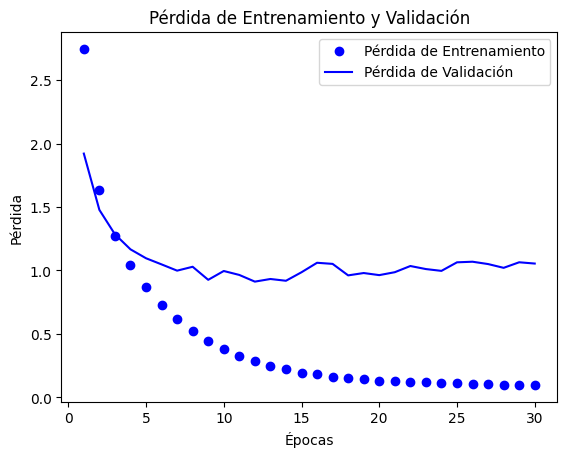

In [36]:
loss_values = modelo_dict['loss']
val_loss_values = modelo_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Pérdida de Entrenamiento')
plt.plot(epochs, val_loss_values, 'b', label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()